✅ Done! Overlays saved in: ./vis P/


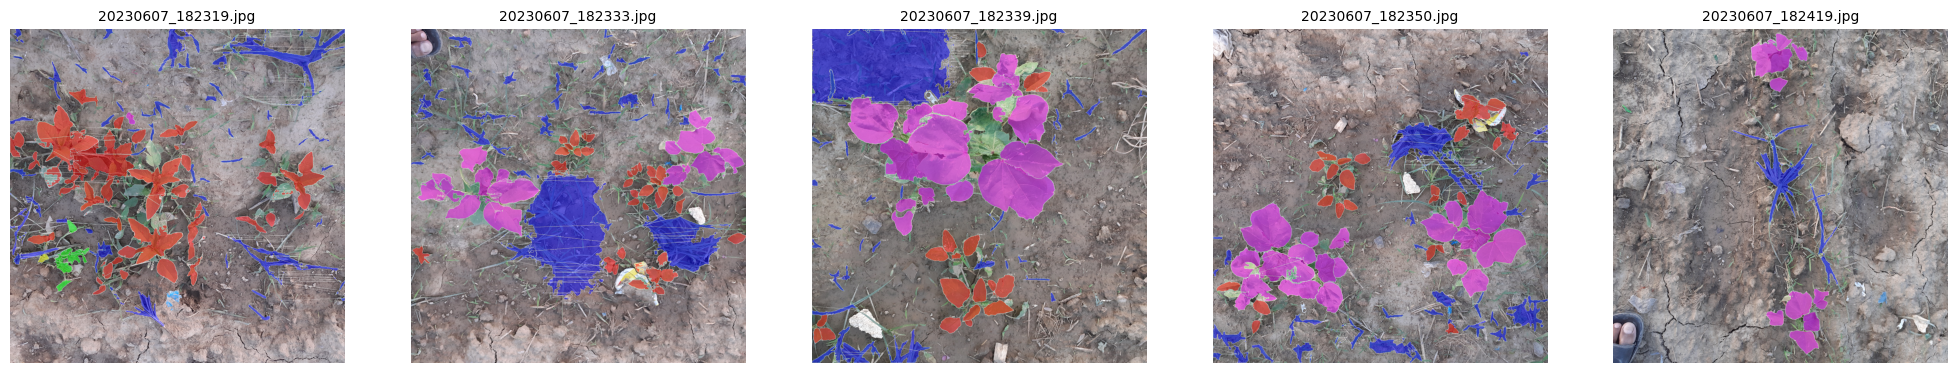

In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# ---------- Helpers ----------
def load_yolo_seg(txt_file, img_size):
    """Load YOLO segmentation polygons from txt file."""
    h, w = img_size
    polygons = []
    if not os.path.exists(txt_file):
        return polygons

    with open(txt_file, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 3:
            continue

        cls = int(float(parts[0]))
        coords = list(map(float, parts[1:]))
        poly = [(int(coords[i] * w), int(coords[i+1] * h)) for i in range(0, len(coords), 2)]
        polygons.append((cls, poly))
    return polygons


def visualize_and_save(image_path, label_path, out_path, num_classes=5, alpha=0.5, max_width=1024):
    """Overlay YOLO segmentation mask on image and save result."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    polygons = load_yolo_seg(label_path, (h, w))

    # fixed distinct colors
    fixed_colors = [
        (255, 0, 0), (0, 255, 0), (0, 0, 255),
        (255, 255, 0), (255, 0, 255), (0, 255, 255)
    ]
    class_colors = {i: fixed_colors[i % len(fixed_colors)] for i in range(num_classes)}

    overlay = img.copy()

    for cls, poly in polygons:
        if len(poly) > 2:
            color = class_colors[cls]
            cv2.fillPoly(overlay, [np.array(poly, dtype=np.int32)], color)
            cv2.polylines(overlay, [np.array(poly, dtype=np.int32)], True, (255,255,255), 2)
            cv2.putText(overlay, f"Class {cls}", poly[0], cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

    blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

    # resize if too wide
    if blended.shape[1] > max_width:
        scale = max_width / blended.shape[1]
        blended = cv2.resize(blended, (int(blended.shape[1]*scale), int(blended.shape[0]*scale)))

    # save
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    cv2.imwrite(out_path, cv2.cvtColor(blended, cv2.COLOR_RGB2BGR))

    return blended  # return result for inline display


# ---------- Batch Processing ----------
images_dir = "./images P/"
labels_dir = "./labels P/"
output_dir = "./vis P/"
preview_count = 5   # show first N overlays in Jupyter

os.makedirs(output_dir, exist_ok=True)

preview_images = []

for i, img_file in enumerate(os.listdir(images_dir)):
    if not img_file.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    img_path = os.path.join(images_dir, img_file)
    label_path = os.path.join(labels_dir, os.path.splitext(img_file)[0] + ".txt")
    out_path = os.path.join(output_dir, os.path.splitext(img_file)[0] + "_overlay.jpg")

    blended = visualize_and_save(img_path, label_path, out_path, num_classes=5)

    if i < preview_count:  # collect first N images for inline display
        preview_images.append((img_file, blended))

print(f"✅ Done! Overlays saved in: {output_dir}")

# ---------- Inline Preview ----------
fig, axes = plt.subplots(1, len(preview_images), figsize=(5*len(preview_images), 5))
if len(preview_images) == 1:
    axes = [axes]

for ax, (name, img) in zip(axes, preview_images):
    ax.imshow(img)
    ax.set_title(name, fontsize=10)
    ax.axis("off")

plt.show()


In [10]:
import os
import numpy as np
from PIL import Image

mask_dir = "C:/Users/PMLS/Downloads/Yolo New/yolov8/image-segmentation-yolov8-main-mine/imagesN/masks"  # <-- change this
unique_colors = set()

for fname in sorted(os.listdir(mask_dir)):
    if not fname.lower().endswith((".png", ".jpg", ".tif")):
        continue
    path = os.path.join(mask_dir, fname)
    try:
        mask = np.array(Image.open(path))
        if mask.ndim == 2:
            # grayscale (values like 0,1,2,3,4,5)
            for v in np.unique(mask):
                unique_colors.add((v, v, v))
        elif mask.ndim == 3:
            # RGB image
            for rgb in np.unique(mask.reshape(-1, 3), axis=0):
                unique_colors.add(tuple(rgb))
    except Exception as e:
        print(f"Error reading {fname}: {e}")

print("✅ Unique RGB values found:", sorted(unique_colors))


✅ Unique RGB values found: [(0, 0, 0), (1, 1, 1), (2, 2, 2), (3, 3, 3), (4, 4, 4), (5, 5, 5)]


In [9]:
import os
import numpy as np
from PIL import Image

mask_dir = "C:/Users/PMLS/Downloads/Yolo New/yolov8/image-segmentation-yolov8-main-mine/imagesN/masks"  # change this
unique_colors = set()

for fname in os.listdir(mask_dir)[:20]:  # check 20 masks
    if fname.endswith(('.png', '.jpg', '.tif')):
        mask = np.array(Image.open(os.path.join(mask_dir, fname)))
        if mask.ndim == 3:
            pixels = mask.reshape(-1, 3)
            for rgb in np.unique(pixels, axis=0):
                unique_colors.add(tuple(rgb))

print("All unique RGBs found:", unique_colors)


All unique RGBs found: set()


In [8]:
import numpy as np
from PIL import Image
import os
DATA_ROOT = 'C:/Users/PMLS/Downloads/Yolo New/yolov8/image-segmentation-yolov8-main-mine/imagesN/'

mask_dir = os.path.join(DATA_ROOT, 'masks')
sample_mask = os.path.join(mask_dir, os.listdir(mask_dir)[0])
mask_rgb = np.array(Image.open(sample_mask).convert("RGB"))

print("Unique RGB values in this mask:")
unique_colors = np.unique(mask_rgb.reshape(-1, 3), axis=0)
print(unique_colors)


Unique RGB values in this mask:
[[0 0 0]
 [3 3 3]]


In [2]:
    import os
    import random

    def create_deeplab_txt_files(image_folder, output_list_folder, train_ratio=0.9):
        """
        Creates train.txt and val.txt files for DeepLab training.

        Args:
            image_folder (str): Path to the folder containing your image files.
            output_list_folder (str): Path to the folder where train.txt and val.txt will be saved.
            train_ratio (float): The proportion of images to allocate to the training set.
        """
        if not os.path.exists(output_list_folder):
            os.makedirs(output_list_folder)

        image_filenames = [os.path.splitext(f)[0] for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]
        random.shuffle(image_filenames)

        num_train = int(len(image_filenames) * train_ratio)
        train_filenames = image_filenames[:num_train]
        val_filenames = image_filenames[num_train:]

        with open(os.path.join(output_list_folder, 'train.txt'), 'w') as f:
            for filename in train_filenames:
                f.write(filename + '\n')

        with open(os.path.join(output_list_folder, 'val.txt'), 'w') as f:
            for filename in val_filenames:
                f.write(filename + '\n')

        print(f"Created train.txt with {len(train_filenames)} images and val.txt with {len(val_filenames)} images.")

    # Example usage:
    # Replace with your actual paths
    image_directory = "./images_compressed"
    list_directory = "./Segmentation"
    create_deeplab_txt_files(image_directory, list_directory)

Created train.txt with 354 images and val.txt with 40 images.


In [2]:
import os
import numpy as np
from PIL import Image, ImageDraw

def yolo_seg_to_mask(txt_file, img_size, num_classes):
    """
    Converts a single YOLO segmentation label file (.txt) to a mask image.

    Args:
        txt_file (str): Path to the YOLO segmentation label file.
        img_size (tuple): A tuple (height, width) specifying the output mask dimensions.
        num_classes (int): The total number of classes in the dataset.

    Returns:
        np.ndarray: The mask image as a NumPy array.
    """
    h, w = img_size
    # Create an empty mask with a background value of 0.
    mask = np.zeros((h, w), dtype=np.int64)

    try:
        with open(txt_file, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"Error: Label file not found at {txt_file}. Skipping.")
        return mask

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 3:
            continue  # Skip malformed lines

        # Extract class ID and coordinates
        try:
            cls = int(float(parts[0]))
            # The label format is class_id x1 y1 x2 y2 ...
            coords = list(map(float, parts[1:]))
        except (ValueError, IndexError):
            print(f"Warning: Skipping malformed line in {txt_file}: {line.strip()}")
            continue

        # Convert normalized coordinates (0 to 1) to pixel coordinates.
        # YOLO coordinates are typically x_center, y_center, width, height for boxes,
        # but for segmentation they are a list of polygon points.
        if len(coords) >= 2:
            poly = [(int(coords[i] * w), int(coords[i+1] * h)) for i in range(0, len(coords), 2)]
            
            # Create a temporary single-channel image to draw the polygon.
            # We use cls + 1 as the fill value to differentiate from the background (0).
            img = Image.fromarray(np.zeros((h, w), dtype=np.uint8))
            ImageDraw.Draw(img).polygon(poly, fill=cls + 1)
            
            # Combine the new polygon with the existing mask.
            # np.maximum ensures that overlapping polygons with different class IDs
            # will be handled correctly by keeping the highest value.
            mask = np.maximum(mask, np.array(img, dtype=np.int64))

    return mask

def bulk_yolo_seg_to_masks(labels_dir, masks_dir, img_size, num_classes):
    """
    Bulk converts all YOLO segmentation label files in a directory to mask images.

    Args:
        labels_dir (str): Path to the directory containing YOLO label files (.txt).
        masks_dir (str): Path to the directory where the generated masks will be saved.
        img_size (tuple): A tuple (height, width) specifying the output mask dimensions.
        num_classes (int): The total number of classes in the dataset.
    """
    if not os.path.exists(masks_dir):
        os.makedirs(masks_dir)
    
    label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]
    
    if not label_files:
        print(f"No .txt files found in the labels directory: {labels_dir}")
        return

    print(f"Found {len(label_files)} label files to process.")
    
    for filename in label_files:
        txt_path = os.path.join(labels_dir, filename)
        
        # Construct the output filename by changing the extension from .txt to .png.
        mask_filename = os.path.splitext(filename)[0] + '.png'
        mask_path = os.path.join(masks_dir, mask_filename)
        
        # Generate the mask.
        mask = yolo_seg_to_mask(txt_path, img_size, num_classes)
        
        # Convert to uint8 and save the image.
        Image.fromarray(mask.astype(np.uint8)).save(mask_path)
        print(f"Converted '{filename}' to '{mask_filename}'")

# Example usage:
if __name__ == "__main__":
    # Define your parameters
    image_height, image_width = 512, 512
    num_classes = 5  # Example: 5 classes, so pixel values will be 1 through 5.
    
    # Define your input and output directories
    labels_folder = './labels/'
    masks_folder = './masks new/'
    
    # Create dummy label files for demonstration purposes
    if not os.path.exists(labels_folder):
        os.makedirs(labels_folder)
    with open(os.path.join(labels_folder, 'image1.txt'), 'w') as f:
        f.write("0 0.2 0.2 0.4 0.2 0.4 0.4 0.2 0.4\n")
        f.write("1 0.6 0.6 0.8 0.6 0.8 0.8 0.6 0.8\n")
    with open(os.path.join(labels_folder, 'image2.txt'), 'w') as f:
        f.write("2 0.1 0.1 0.3 0.1 0.2 0.3 0.1 0.3\n")
    
    # Run the bulk conversion
    bulk_yolo_seg_to_masks(labels_folder, masks_folder, (image_height, image_width), num_classes)
    
    print("\nBulk conversion complete. Check the 'masks' directory for results.")



Found 396 label files to process.
Converted '20230604_094614.txt' to '20230604_094614.png'
Converted '20230604_094621.txt' to '20230604_094621.png'
Converted '20230604_123727.txt' to '20230604_123727.png'
Converted '20230604_123731.txt' to '20230604_123731.png'
Converted '20230604_123735.txt' to '20230604_123735.png'
Converted '20230604_123740.txt' to '20230604_123740.png'
Converted '20230604_123743.txt' to '20230604_123743.png'
Converted '20230604_123923.txt' to '20230604_123923.png'
Converted '20230604_124150.txt' to '20230604_124150.png'
Converted '20230604_124153.txt' to '20230604_124153.png'
Converted '20230604_124154.txt' to '20230604_124154.png'
Converted '20230604_124157.txt' to '20230604_124157.png'
Converted '20230604_124204.txt' to '20230604_124204.png'
Converted '20230604_124223.txt' to '20230604_124223.png'
Converted '20230604_124226.txt' to '20230604_124226.png'
Converted '20230604_124244.txt' to '20230604_124244.png'
Converted '20230604_124250.txt' to '20230604_124250.pn

In [1]:
from PIL import Image
import os

in_dir = "./images/"
out_dir = "./images_compressed/"
os.makedirs(out_dir, exist_ok=True)

for file in os.listdir(in_dir):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        img = Image.open(os.path.join(in_dir, file))
        out_path = os.path.join(out_dir, file.replace(".png", ".jpg"))  # save as jpg
        img.save(out_path, "JPEG", quality=85)  # adjust quality (80–90 good range)


In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import random

# ---------- Helpers ----------
def load_yolo_seg(txt_file, img_size):
    """Load YOLO segmentation polygons from txt file."""
    h, w = img_size
    polygons = []
    if not os.path.exists(txt_file):
        return polygons

    with open(txt_file, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 3:
            continue

        cls = int(float(parts[0]))
        coords = list(map(float, parts[1:]))
        poly = [(int(coords[i] * w), int(coords[i+1] * h)) for i in range(0, len(coords), 2)]
        polygons.append((cls, poly))
    return polygons


def visualize_and_save(image_path, label_path, out_path, num_classes=5, alpha=0.5, max_width=1024):
    """Overlay YOLO segmentation mask on image and save result."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    polygons = load_yolo_seg(label_path, (h, w))

    # fixed distinct colors
    fixed_colors = [
        (255, 0, 0), (0, 255, 0), (0, 0, 255),
        (255, 255, 0), (255, 0, 255), (0, 255, 255)
    ]
    class_colors = {i: fixed_colors[i % len(fixed_colors)] for i in range(num_classes)}

    overlay = img.copy()

    for cls, poly in polygons:
        if len(poly) > 2:
            color = class_colors[cls]
            cv2.fillPoly(overlay, [np.array(poly, dtype=np.int32)], color)
            cv2.polylines(overlay, [np.array(poly, dtype=np.int32)], True, (255,255,255), 2)
            cv2.putText(overlay, f"Class {cls}", poly[0], cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

    blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

    # resize if too wide
    if blended.shape[1] > max_width:
        scale = max_width / blended.shape[1]
        blended = cv2.resize(blended, (int(blended.shape[1]*scale), int(blended.shape[0]*scale)))

    # save
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    cv2.imwrite(out_path, cv2.cvtColor(blended, cv2.COLOR_RGB2BGR))

    return blended


# ---------- Batch Processing ----------
images_dir = "./images"
labels_dir = "./labels"
output_dir = "./vis"
preview_count = 5   # number of random samples to show in Jupyter
num_classes = 5     # adjust for your dataset

os.makedirs(output_dir, exist_ok=True)

all_images = [f for f in os.listdir(images_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

preview_images = []

for img_file in all_images:
    img_path = os.path.join(images_dir, img_file)
    label_path = os.path.join(labels_dir, os.path.splitext(img_file)[0] + ".txt")
    out_path = os.path.join(output_dir, os.path.splitext(img_file)[0] + "_overlay.jpg")

    blended = visualize_and_save(img_path, label_path, out_path, num_classes=num_classes)

# pick random preview set
sampled = random.sample(all_images, min(preview_count, len(all_images)))
for img_file in sampled:
    preview_path = os.path.join(output_dir, os.path.splitext(img_file)[0] + "_overlay.jpg")
    blended = cv2.cvtColor(cv2.imread(preview_path), cv2.COLOR_BGR2RGB)
    preview_images.append((img_file, blended))

print(f"✅ Done! Overlays saved in: {output_dir}")

# ---------- Inline Preview ----------
fig, axes = plt.subplots(1, len(preview_images), figsize=(5*len(preview_images), 5))
if len(preview_images) == 1:
    axes = [axes]

for ax, (name, img) in zip(axes, preview_images):
    ax.imshow(img)
    ax.set_title(name, fontsize=10)
    ax.axis("off")

plt.show()


Drawing class 4 with 351 points
Drawing class 4 with 701 points
Drawing class 4 with 422 points
Drawing class 4 with 810 points
Drawing class 4 with 650 points
Drawing class 4 with 319 points
Drawing class 4 with 663 points
Drawing class 4 with 393 points
Drawing class 4 with 758 points
Drawing class 4 with 571 points
Drawing class 3 with 276 points
Drawing class 3 with 336 points
Drawing class 3 with 455 points
Drawing class 3 with 142 points
Drawing class 3 with 188 points
Drawing class 3 with 184 points


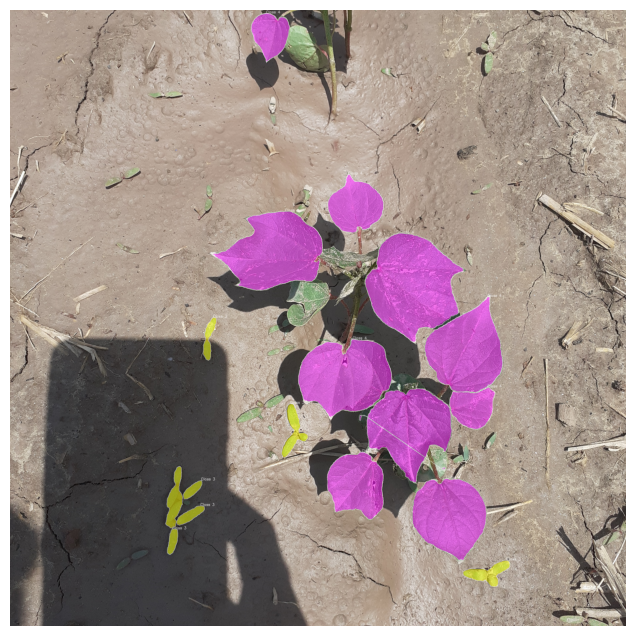

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_yolo_seg(txt_file, img_size):
    """Load YOLO segmentation polygons from txt file."""
    h, w = img_size
    polygons = []

    with open(txt_file, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 3:
            continue

        cls = int(float(parts[0]))
        coords = list(map(float, parts[1:]))
        poly = [(int(coords[i] * w), int(coords[i+1] * h)) for i in range(0, len(coords), 2)]
        polygons.append((cls, poly))
    return polygons


def visualize_segmentation_jupyter(image_path, label_path, num_classes, alpha=0.5):
    """Overlay YOLO segmentation mask on original image (Jupyter-friendly)."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV → matplotlib format
    h, w = img.shape[:2]

    polygons = load_yolo_seg(label_path, (h, w))

    # fixed colors (red, green, blue, yellow, magenta, cyan, ...)
    fixed_colors = [
        (255, 0, 0), (0, 255, 0), (0, 0, 255),
        (255, 255, 0), (255, 0, 255), (0, 255, 255)
    ]
    class_colors = {i: fixed_colors[i % len(fixed_colors)] for i in range(num_classes)}

    overlay = img.copy()

    for cls, poly in polygons:
        print(f"Drawing class {cls} with {len(poly)} points")  # will show in notebook
        color = class_colors[cls]

        if len(poly) > 2:  # polygon must have at least 3 points
            cv2.fillPoly(overlay, [np.array(poly, dtype=np.int32)], color)
            cv2.polylines(overlay, [np.array(poly, dtype=np.int32)], True, (255,255,255), 2)
            cv2.putText(overlay, f"Class {cls}", poly[0], cv2.FONT_HERSHEY_SIMPLEX, 
                        0.6, (255,255,255), 2)

    blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

    # Show inline in Jupyter
    plt.figure(figsize=(8, 8))
    plt.imshow(blended)
    plt.axis("off")
    plt.show()

    return blended


# Example usage
image_path = "./images/20230604_123727.jpg"
label_path = "./labels/20230604_123727.txt"
_ = visualize_segmentation_jupyter(image_path, label_path, num_classes=5)


In [ ]:
from PIL import Image
import numpy as np
import os

# Define your color → class mapping
# Format: (R, G, B) : class_id
color2id = {
    (0, 0, 0): 0,        # background = black
    (0, 255, 0): 1,      # green = crop
    (255, 0, 0): 2,      # red = weed
    (0, 0, 255): 3       # blue = soil (example)
}

def rgb_to_class_mask(rgb_mask):
    rgb_mask = np.array(rgb_mask)
    h, w, _ = rgb_mask.shape
    mask = np.zeros((h, w), dtype=np.int64)

    for color, idx in color2id.items():
        mask[np.all(rgb_mask == color, axis=-1)] = idx
    
    return mask

# Example usage
input_dir = "rgb_masks"
output_dir = "class_masks"
os.makedirs(output_dir, exist_ok=True)

for file in os.listdir(input_dir):
    rgb_mask = Image.open(os.path.join(input_dir, file)).convert("RGB")
    class_mask = rgb_to_class_mask(rgb_mask)
    out_path = os.path.join(output_dir, file.replace(".png", "_class.png"))
    Image.fromarray(class_mask.astype(np.uint8)).save(out_path)


In [ ]:
from ultralytics.data.annotator import auto_annotate

auto_annotate(
    data="path/to/your/images",  # Path to your images
    det_model="yolo11n.pt",     # Your trained YOLO detection model
    sam_model="sam2-t.pt",      # SAM 2 Tiny model
    device="cuda",              # Or "cpu" if no GPU is available
    output_dir="path/to/save_labels", # Directory to save generated labels
)

In [2]:
from ultralytics.data.converter import yolo_bbox2segment
# Assuming your images are in 'path/to/images' and YOLO labels in 'path/to/labels'
yolo_bbox2segment(
    im_dir="C:/Users/PMLS/Desktop/From old Hard/Med No Background/Done/images/",
    save_dir="C:/Users/PMLS/Desktop/From old Hard/Med No Background/Done/labels-seg",
#    yolo_model_path="C:/Users/PMLS/Downloads/yolo11n.pt",
    sam_model="C:/Users/PMLS/Downloads/SAMs/sam2.1_t.pt"
)

Fast image access  (ping: 0.10.1 ms, read: 212.435.4 MB/s, size: 7064.1 KB)
Scanning C:\Users\PMLS\Desktop\From old Hard\Med No Background\Done\labels... 394 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 394/394 372.8it/s 1.1s0.0s
New cache created: C:\Users\PMLS\Desktop\From old Hard\Med No Background\Done\labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
Detection labels detected, generating segment labels by SAM model!


C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\models\sam\build.py:305: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)["model"]


Generating segment labels: 100% ━━━━━━━━━━━━ 394/394 0.1it/s 59:41<6.5s3
Generated segment labels saved in C:\Users\PMLS\Desktop\From old Hard\Med No Background\Done\labels-seg


In [24]:
from ultralytics.data.annotator import auto_annotate

auto_annotate(data="C:/Users/PMLS/Downloads/Yolo New/yolov8/image-segmentation-yolov8-main-mine/tmp/BTSSAM2/train/weed", 
              det_model="C:/Users/PMLS/Downloads/Yolo New/yolov8/image-segmentation-yolov8-main-mine/yolo11m.pt", 
              sam_model="C:/Users/PMLS/Downloads/SAMs/sam2_b.pt")


image 1/8 C:\Users\PMLS\Downloads\Yolo New\yolov8\image-segmentation-yolov8-main-mine\tmp\BTSSAM2\train\weed\Blue (1).jpg: 480x640 1 potted plant, 742.0ms
image 2/8 C:\Users\PMLS\Downloads\Yolo New\yolov8\image-segmentation-yolov8-main-mine\tmp\BTSSAM2\train\weed\Blue (2).jpg: 480x640 (no detections), 676.6ms
image 3/8 C:\Users\PMLS\Downloads\Yolo New\yolov8\image-segmentation-yolov8-main-mine\tmp\BTSSAM2\train\weed\Blue (3).jpg: 480x640 (no detections), 619.7ms
image 4/8 C:\Users\PMLS\Downloads\Yolo New\yolov8\image-segmentation-yolov8-main-mine\tmp\BTSSAM2\train\weed\Nutsedge (26).jpeg: 640x640 (no detections), 849.3ms
image 5/8 C:\Users\PMLS\Downloads\Yolo New\yolov8\image-segmentation-yolov8-main-mine\tmp\BTSSAM2\train\weed\Nutsedge (27).jpeg: 640x480 (no detections), 706.4ms
image 6/8 C:\Users\PMLS\Downloads\Yolo New\yolov8\image-segmentation-yolov8-main-mine\tmp\BTSSAM2\train\weed\Nutsedge (28).jpeg: 640x480 (no detections), 727.1ms
image 7/8 C:\Users\PMLS\Downloads\Yolo New\yol

In [ ]:
import os
import cv2
import supervision as sv
from ultralytics import SAM

# Paths
images_dir = "C:/Users/PMLS/Downloads/Yolo New/yolov8/image-segmentation-yolov8-main-mine/tmp/BTS/images/train"   # folder with input images
output_dir = "C:/Users/PMLS/Downloads/Yolo New/yolov8/image-segmentation-yolov8-main-mine/tmp/BTS/overlays"  # where overlays will be saved
os.makedirs(output_dir, exist_ok=True)

# Load SAM model
sam = SAM("C:/Users/PMLS/Downloads/sam_b.pt")

# Create mask annotator
mask_annotator = sv.MaskAnnotator()

# Loop through images
for filename in os.listdir(images_dir):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):
        image_path = os.path.join(images_dir, filename)
        image = cv2.imread(image_path)

        if image is None:
            print(f"⚠️ Skipping {filename} (could not read)")
            continue

        # Run SAM
        results = sam.predict(image)[0]

        # Convert to Supervision detections
        detections = sv.Detections.from_ultralytics(results)

        # Overlay masks
        annotated_image = mask_annotator.annotate(scene=image.copy(), detections=detections)

        # Save result
        save_path = os.path.join(output_dir, filename)
        cv2.imwrite(save_path, annotated_image)
        print(f"✅ Saved overlay: {save_path}")

print("🎉 All overlays generated!")



0: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 1 38, 1 39, 1 40, 1 41, 1 42, 1 43, 1 44, 1 45, 1 46, 1 47, 1 48, 1 49, 1 50, 1 51, 1 52, 1 53, 1 54, 1 55, 1 56, 1 57, 1 58, 1 59, 1 60, 1 61, 1 62, 1 63, 1 64, 1 65, 1 66, 1 67, 1 68, 1 69, 1 70, 1 71, 1 72, 1 73, 1 74, 1 75, 1 76, 1 77, 1 78, 1 79, 1 80, 1 81, 1 82, 1 83, 1 84, 1 85, 361191.6ms
Speed: 33.8ms preprocess, 361191.6ms inference, 528.1ms postprocess per image at shape (1, 3, 1024, 1024)
✅ Saved overlay: C:/Users/PMLS/Downloads/Yolo New/yolov8/image-segmentation-yolov8-main-mine/tmp/BTS/overlays\20220129_CanonEOS4000D_EO_20.jpg

0: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 

In [ ]:
import cv2
import supervision as sv
from ultralytics import YOLO

# Example usage — adjust to your context
model = YOLO("C:/Users/PMLS/Downloads/yolo11n-seg.pt")  # if using YOLO segmentation model
image = cv2.imread("C:/Users/PMLS/Downloads/Yolo New/yolov8/image-segmentation-yolov8-main-mine/tmp/BTS/images/train/20220129_CanonEOS4000D_EO_35.jpg")
results = model.predict(image)[0]
detections = sv.Detections.from_ultralytics(results)

mask_annotator = sv.MaskAnnotator()
labeled_image = mask_annotator.annotate(scene=image, detections=detections)
sv.plot_image(labeled_image)



0: 640x448 (no detections), 487.0ms
Speed: 6.5ms preprocess, 487.0ms inference, 7.3ms postprocess per image at shape (1, 3, 640, 448)


In [2]:

import os
import cv2
import numpy as np

input_dir = 'C:/Users/PMLS/Downloads/Yolo New/yolov8/image-segmentation-yolov8-main-mine/tmp/masks RE'   # Input directory: Example- './project/masks'
output_dir = 'C:/Users/PMLS/Downloads/Yolo New/yolov8/image-segmentation-yolov8-main-mine/tmp/labels RE'  # Output directory: Example- './project/labels'

# Define the classes and their corresponding color values in the order of the .yaml file
classes = [
   
    ((255, 0, 0), 'weed'),
    ((0, 255, 0), 'Sunflower'),
    ((0, 0, 255), 'Background')]
    # Above is an example of some classes used
    # Format: ((R,G,B), 'name of class') Make sure ordering matches your .yaml file.


# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

for image_name in os.listdir(input_dir):
    image_path = os.path.join(input_dir, image_name)
    # Load the binary mask image
    mask = cv2.imread(image_path, cv2.IMREAD_COLOR)

    H, W, _ = mask.shape
    mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    # Convert the RGB values of mask to tuples
    mask_rgb_tuples = [tuple(pixel) for pixel in mask_rgb.reshape(-1, 3)]

    # Find unique RGB tuples in the mask image
    unique_rgb_tuples = list(set(mask_rgb_tuples))

    # Filter out tuples not present in the classes list
    valid_rgb_tuples = [rgb_tuple for rgb_tuple in unique_rgb_tuples if rgb_tuple in [c[0] for c in classes]]

    # Initialize the polygons list to store polygons for each class
    polygons = []

    # Find contours for each valid RGB tuple and add them to the polygons list
    for rgb_tuple in valid_rgb_tuples:
        class_name = [c[1] for c in classes if c[0] == rgb_tuple][0]
        mask_rgb_indices = [i for i, x in enumerate(mask_rgb_tuples) if x == rgb_tuple]
        lower_bound = np.array([rgb_tuple[2], rgb_tuple[1], rgb_tuple[0]], dtype=np.uint8)
        upper_bound = np.array([rgb_tuple[2], rgb_tuple[1], rgb_tuple[0]], dtype=np.uint8)
        mask_binary = cv2.inRange(mask, lower_bound, upper_bound)
        mask_contour, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in mask_contour:
            if cv2.contourArea(contour) > 10:
                polygon = []
                for point in contour:
                    x, y = point[0]
                    polygon.append(x / W)
                    polygon.append(y / H)
                polygons.append((polygon, class_name))

    if polygons:
        # Save the polygons to the corresponding output file
        output_file = os.path.join(output_dir, '{}.txt'.format(image_name[:-4]))
        with open(output_file, 'w') as f:
            for polygon, class_name in polygons:
                class_number = [c[1] for c in classes].index(class_name)
                f.write('{} '.format(class_number))
                for p in polygon:
                    f.write('{} '.format(p))
                f.write('\n')

    print('Processed:', image_name)

print('Polygon extraction completed.')


Processed: 004_frame0007_GroundTruth_color.png
Processed: 004_frame0015_GroundTruth_color.png
Processed: 004_frame0016_GroundTruth_color.png
Processed: 004_frame0017_GroundTruth_color.png
Processed: 004_frame0024_GroundTruth_color.png
Processed: 004_frame0025_GroundTruth_color.png
Processed: 004_frame0026_GroundTruth_color.png
Processed: 004_frame0032_GroundTruth_color.png
Processed: 004_frame0033_GroundTruth_color.png
Processed: 004_frame0034_GroundTruth_color.png
Processed: 004_frame0035_GroundTruth_color.png
Processed: 004_frame0040_GroundTruth_color.png
Processed: 004_frame0041_GroundTruth_color.png
Processed: 004_frame0042_GroundTruth_color.png
Processed: 004_frame0043_GroundTruth_color.png
Processed: 004_frame0044_GroundTruth_color.png
Processed: 004_frame0045_GroundTruth_color.png
Processed: 004_frame0046_GroundTruth_color.png
Processed: 004_frame0049_GroundTruth_color.png
Processed: 004_frame0050_GroundTruth_color.png
Processed: 004_frame0051_GroundTruth_color.png
Processed: 00